<a href="https://colab.research.google.com/github/Hiro9ki/invader-game/blob/main/%E3%82%A4%E3%83%B3%E3%82%BD%E3%83%BC%E3%83%AB%E3%82%BB%E3%83%B3%E3%82%B5%E3%81%AE%E9%85%8D%E7%BD%AE_%E5%BA%A7%E6%A8%99%E8%BB%B8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

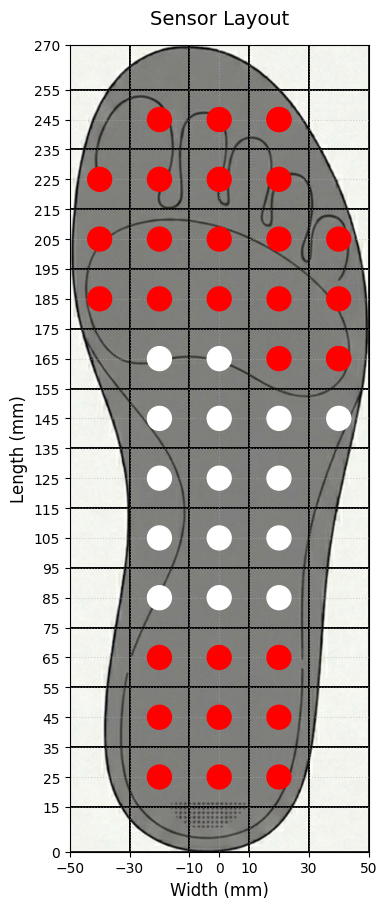

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image # Pillowライブラリをインポート

# --- パラメータ設定 (単位: mm) ---
# 全体領域のサイズ (横270mm, 縦230mm)
total_width = 270.0
total_height = 230.0

# マス目の設定
cols = 5
rows = 14
grid_width = 20.0  # 各マスの横幅
total_grid_width = cols * grid_width

# 縦方向の各行の高さリスト (上から順に 15mm, 20mm*12, 15mm)
row_heights = [15.0] + [20.0] * 12 + [15.0]
total_grid_height = sum(row_heights)

# 座標の基準: X軸は中心を0、Y軸は0からスタートさせる
grid_min_x = -total_grid_width / 2.0
grid_max_x = total_grid_width / 2.0
# Y軸の開始点を0に設定
grid_min_y = 0.0
grid_max_y = total_grid_height

# --- 描画のセットアップ ---
fig, ax = plt.subplots(figsize=(10.8, 9.2)) # アスペクト比 27:23 に合わせたウィンドウサイズ

# --- インソール画像の読み込みと配置 ---
image_path = '/content/Insole_27cm_10cm_Google_Colab用.png'

try:
    # 画像を読み込む
    img = Image.open(image_path)
    # 画像を背景として配置。extentはグリッドの表示範囲に合わせる。
    ax.imshow(img, extent=[grid_min_x, grid_max_x, grid_min_y, grid_max_y], aspect='auto', zorder=0)
except FileNotFoundError:
    print(f"Warning: Insole image not found at {image_path}. Skipping image display.")
except Exception as e:
    print(f"Warning: Could not load insole image: {e}. Skipping image display.")

# --- 各マスを描画 (格子の左下を原点 (0,0) とするY軸) ---
# 下から順に上に向かって配置していきます
current_y = grid_min_y # Y座標を0からスタート

for r in range(rows):
    # 下から配置するため、row_heightsを逆順に処理
    h = row_heights[rows - 1 - r]

    for c in range(cols):
        # x座標は格子の左端 (-50.0) から順に配置
        x = grid_min_x + (c * grid_width)
        y = current_y

        # マス目（矩形）を作成
        rect = patches.Rectangle(
            (x, y), grid_width, h,
            linewidth=1.2,
            edgecolor='black',
            facecolor='none',
            zorder=1  # 画像より前面に描画
        )
        ax.add_patch(rect)
    current_y += h  # y座標を1行分上げる

# --- 直径8mmの円を配置 ---
circle_radius = 8 / 2  # 直径8mmなので半径は4mm

# 赤い円の座標リスト
red_circle_coords = [
    (0, 25),
    (-20, 25), (-20, 45), (0, 45), (20, 25), (20, 45),
    (-40, 185), (-40, 205), (-20, 185), (-20, 205), (0, 185), (0, 205),
    (20, 165), (20, 185), (40,165), (40,165), (40,185), (-20, 65), (20, 65),
    (0, 65), (20, 205), (40, 205),(-40, 225), (-20, 225), (0, 225), (20, 225),
    (20, 245), (0, 245), (20, 245), (-20, 245)
]

for cx, cy in red_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='red', edgecolor='red', zorder=2
    )
    ax.add_patch(circle)

# 白い円の座標リスト
white_circle_coords = [
    (-20, 85), (-20, 105), (-20, 125), (-20, 145), (-20, 165),
    (0, 85), (0, 105), (0, 125), (0, 145), (0, 165),
    (20, 85), (20, 105), (20, 125), (20, 145), (40, 145),
]

for cx, cy in white_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='white', edgecolor='white', zorder=2
    )
    ax.add_patch(circle)

# --- グラフのレイアウト調整 ---
# 描画範囲を調整 (X軸は-50mmから50mm、Y軸は0mmからtotal_grid_heightmmまで)
ax.set_xlim(-50, 50)
ax.set_ylim(0, 270)

# アスペクト比を1:1に固定（1mmが画面上で同じ長さになるようにする）
ax.set_aspect('equal')

# 軸ラベルの設定 (mm表示)
ax.set_xlabel('Width (mm)', fontsize=12)
ax.set_ylabel('Length (mm)', fontsize=12)
ax.set_title('Sensor Layout', fontsize=14, pad=15)

# グリッドや目盛りを10mm単位で表示（Y軸は0から）
ax.set_yticks(range(0, 271, 10))
ax.grid(True, which='both', linestyle=':', alpha=0.5, zorder=0.5)

specific_ticks = [-50, -30, -10, 0, 10 ,30, 50]
ax.set_xticks(specific_ticks)

specific_ticks = [0, 15, 25, 35 ,45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 270]
ax.set_yticks(specific_ticks)

plt.tight_layout()
plt.show()

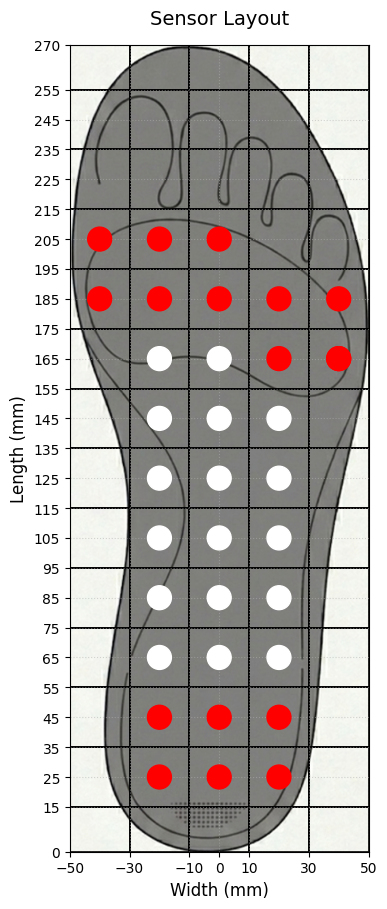

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image # Pillowライブラリをインポート

# --- パラメータ設定 (単位: mm) ---
# 全体領域のサイズ (横270mm, 縦230mm)
total_width = 270.0
total_height = 230.0

# マス目の設定
cols = 5
rows = 14
grid_width = 20.0  # 各マスの横幅
total_grid_width = cols * grid_width

# 縦方向の各行の高さリスト (上から順に 15mm, 20mm*12, 15mm)
row_heights = [15.0] + [20.0] * 12 + [15.0]
total_grid_height = sum(row_heights)

# 座標の基準: X軸は中心を0、Y軸は0からスタートさせる
grid_min_x = -total_grid_width / 2.0
grid_max_x = total_grid_width / 2.0
# Y軸の開始点を0に設定
grid_min_y = 0.0
grid_max_y = total_grid_height

# --- 描画のセットアップ ---
fig, ax = plt.subplots(figsize=(10.8, 9.2)) # アスペクト比 27:23 に合わせたウィンドウサイズ

# --- インソール画像の読み込みと配置 ---
image_path = '/content/Insole_27cm_10cm_Google_Colab用.png'

try:
    # 画像を読み込む
    img = Image.open(image_path)
    # 画像を背景として配置。extentはグリッドの表示範囲に合わせる。
    ax.imshow(img, extent=[grid_min_x, grid_max_x, grid_min_y, grid_max_y], aspect='auto', zorder=0)
except FileNotFoundError:
    print(f"Warning: Insole image not found at {image_path}. Skipping image display.")
except Exception as e:
    print(f"Warning: Could not load insole image: {e}. Skipping image display.")

# --- 各マスを描画 (格子の左下を原点 (0,0) とするY軸) ---
# 下から順に上に向かって配置していきます
current_y = grid_min_y # Y座標を0からスタート

for r in range(rows):
    # 下から配置するため、row_heightsを逆順に処理
    h = row_heights[rows - 1 - r]

    for c in range(cols):
        # x座標は格子の左端 (-50.0) から順に配置
        x = grid_min_x + (c * grid_width)
        y = current_y

        # マス目（矩形）を作成
        rect = patches.Rectangle(
            (x, y), grid_width, h,
            linewidth=1.2,
            edgecolor='black',
            facecolor='none',
            zorder=1  # 画像より前面に描画
        )
        ax.add_patch(rect)
    current_y += h  # y座標を1行分上げる

# --- 直径8mmの円を配置 ---
circle_radius = 8 / 2  # 直径8mmなので半径は4mm

# 赤い円の座標リスト
red_circle_coords = [
    (0, 25),
    (-20, 25), (-20, 45), (0, 45), (20, 25), (20, 45),
    (-40, 185), (-40, 205), (-20, 185), (-20, 205), (0, 185), (0, 205),
    (20, 165), (20, 185), (40,165), (40,165), (40,185)
]

for cx, cy in red_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='red', edgecolor='red', zorder=2
    )
    ax.add_patch(circle)

# 白い円の座標リスト
white_circle_coords = [
    (-20, 65), (-20, 85), (-20, 105), (-20, 125), (-20, 145), (-20, 165),
    (0, 65), (0, 85), (0, 105), (0, 125), (0, 145), (0, 165),
    (20, 65), (20, 85), (20, 105), (20, 125), (20, 145)
]

for cx, cy in white_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='white', edgecolor='white', zorder=2
    )
    ax.add_patch(circle)

# --- グラフのレイアウト調整 ---
# 描画範囲を調整 (X軸は-50mmから50mm、Y軸は0mmからtotal_grid_heightmmまで)
ax.set_xlim(-50, 50)
ax.set_ylim(0, 270)

# アスペクト比を1:1に固定（1mmが画面上で同じ長さになるようにする）
ax.set_aspect('equal')

# 軸ラベルの設定 (mm表示)
ax.set_xlabel('Width (mm)', fontsize=12)
ax.set_ylabel('Length (mm)', fontsize=12)
ax.set_title('Sensor Layout', fontsize=14, pad=15)

# グリッドや目盛りを10mm単位で表示（Y軸は0から）
ax.set_yticks(range(0, 271, 10))
ax.grid(True, which='both', linestyle=':', alpha=0.5, zorder=0.5)

specific_ticks = [-50, -30, -10, 0, 10 ,30, 50]
ax.set_xticks(specific_ticks)

specific_ticks = [0, 15, 25, 35 ,45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 270]
ax.set_yticks(specific_ticks)

plt.tight_layout()
plt.show()

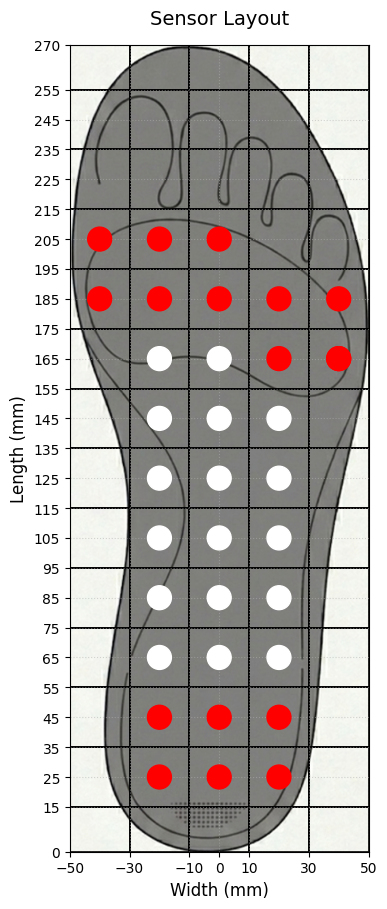

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image # Pillowライブラリをインポート

# --- パラメータ設定 (単位: mm) ---
# 全体領域のサイズ (横270mm, 縦230mm)
total_width = 270.0
total_height = 230.0

# マス目の設定
cols = 5
rows = 14
grid_width = 20.0  # 各マスの横幅
total_grid_width = cols * grid_width

# 縦方向の各行の高さリスト (上から順に 15mm, 20mm*12, 15mm)
row_heights = [15.0] + [20.0] * 12 + [15.0]
total_grid_height = sum(row_heights)

# 座標の基準: X軸は中心を0、Y軸は0からスタートさせる
grid_min_x = -total_grid_width / 2.0
grid_max_x = total_grid_width / 2.0
# Y軸の開始点を0に設定
grid_min_y = 0.0
grid_max_y = total_grid_height

# --- 描画のセットアップ ---
fig, ax = plt.subplots(figsize=(10.8, 9.2)) # アスペクト比 27:23 に合わせたウィンドウサイズ

# --- インソール画像の読み込みと配置 ---
image_path = '/content/Insole_27cm_10cm_Google_Colab用.png'

try:
    # 画像を読み込む
    img = Image.open(image_path)
    # 画像を背景として配置。extentはグリッドの表示範囲に合わせる。
    ax.imshow(img, extent=[grid_min_x, grid_max_x, grid_min_y, grid_max_y], aspect='auto', zorder=0)
except FileNotFoundError:
    print(f"Warning: Insole image not found at {image_path}. Skipping image display.")
except Exception as e:
    print(f"Warning: Could not load insole image: {e}. Skipping image display.")

# --- 各マスを描画 (格子の左下を原点 (0,0) とするY軸) ---
# 下から順に上に向かって配置していきます
current_y = grid_min_y # Y座標を0からスタート

for r in range(rows):
    # 下から配置するため、row_heightsを逆順に処理
    h = row_heights[rows - 1 - r]

    for c in range(cols):
        # x座標は格子の左端 (-50.0) から順に配置
        x = grid_min_x + (c * grid_width)
        y = current_y

        # マス目（矩形）を作成
        rect = patches.Rectangle(
            (x, y), grid_width, h,
            linewidth=1.2,
            edgecolor='black',
            facecolor='none',
            zorder=1  # 画像より前面に描画
        )
        ax.add_patch(rect)
    current_y += h  # y座標を1行分上げる

# --- 直径8mmの円を配置 ---
circle_radius = 8 / 2  # 直径8mmなので半径は4mm

# 赤い円の座標リスト
red_circle_coords = [
    (0, 25),
    (-20, 25), (-20, 45), (0, 45), (20, 25), (20, 45),
    (-40, 185), (-40, 205), (-20, 185), (-20, 205), (0, 185), (0, 205),
    (20, 165), (20, 185), (40,165), (40,165), (40,185)
]

for cx, cy in red_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='red', edgecolor='red', zorder=2
    )
    ax.add_patch(circle)

# 白い円の座標リスト
white_circle_coords = [
    (-20, 65), (-20, 85), (-20, 105), (-20, 125), (-20, 145), (-20, 165),
    (0, 65), (0, 85), (0, 105), (0, 125), (0, 145), (0, 165),
    (20, 65), (20, 85), (20, 105), (20, 125), (20, 145)
]

for cx, cy in white_circle_coords:
    circle = patches.Circle(
        (cx, cy), circle_radius,
        facecolor='white', edgecolor='white', zorder=2
    )
    ax.add_patch(circle)

# --- グラフのレイアウト調整 ---
# 描画範囲を調整 (X軸は-50mmから50mm、Y軸は0mmからtotal_grid_heightmmまで)
ax.set_xlim(-50, 50)
ax.set_ylim(0, 270)

# アスペクト比を1:1に固定（1mmが画面上で同じ長さになるようにする）
ax.set_aspect('equal')

# 軸ラベルの設定 (mm表示)
ax.set_xlabel('Width (mm)', fontsize=12)
ax.set_ylabel('Length (mm)', fontsize=12)
ax.set_title('Sensor Layout', fontsize=14, pad=15)

# グリッドや目盛りを10mm単位で表示（Y軸は0から）
ax.set_yticks(range(0, 271, 10))
ax.grid(True, which='both', linestyle=':', alpha=0.5, zorder=0.5)

specific_ticks = [-50, -30, -10, 0, 10 ,30, 50]
ax.set_xticks(specific_ticks)

specific_ticks = [0, 15, 25, 35 ,45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 270]
ax.set_yticks(specific_ticks)

plt.tight_layout()
plt.show()